In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

   Experience  Salary
0           1   25000
1           2   30000
2           3   35000
3           4   45000
4           5   50000
5           6   60000
6           7   65000
7           8   80000
8           9   85000
9          10   95000

Predictions:
[80000. 25000.]

Mean Squared Error : 25000000.0
Mean Absolute Error: 5000.0
R2 Score           : 0.9669421487603306

Predicted Salary for 6.5 years experience:
60000.0


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Local\Temp\ipykernel_1124\3990064538.py:96: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values), max(X.values), 0.1)
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


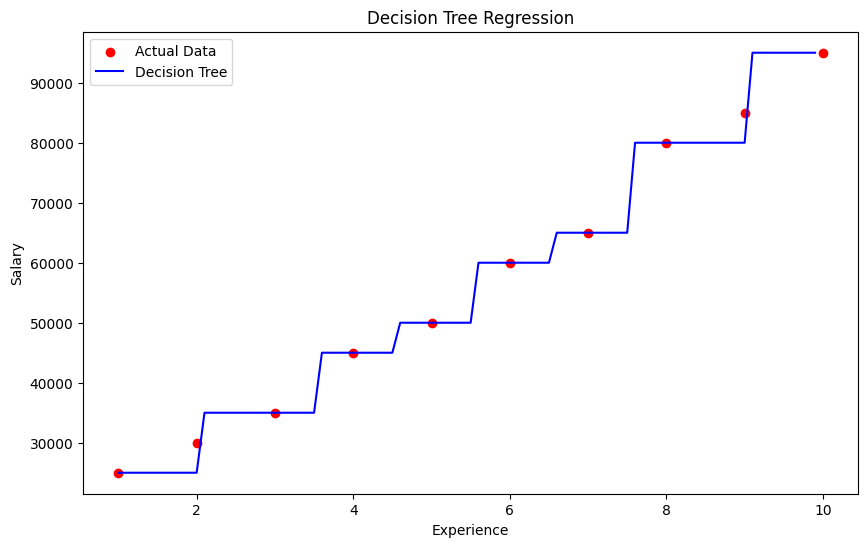

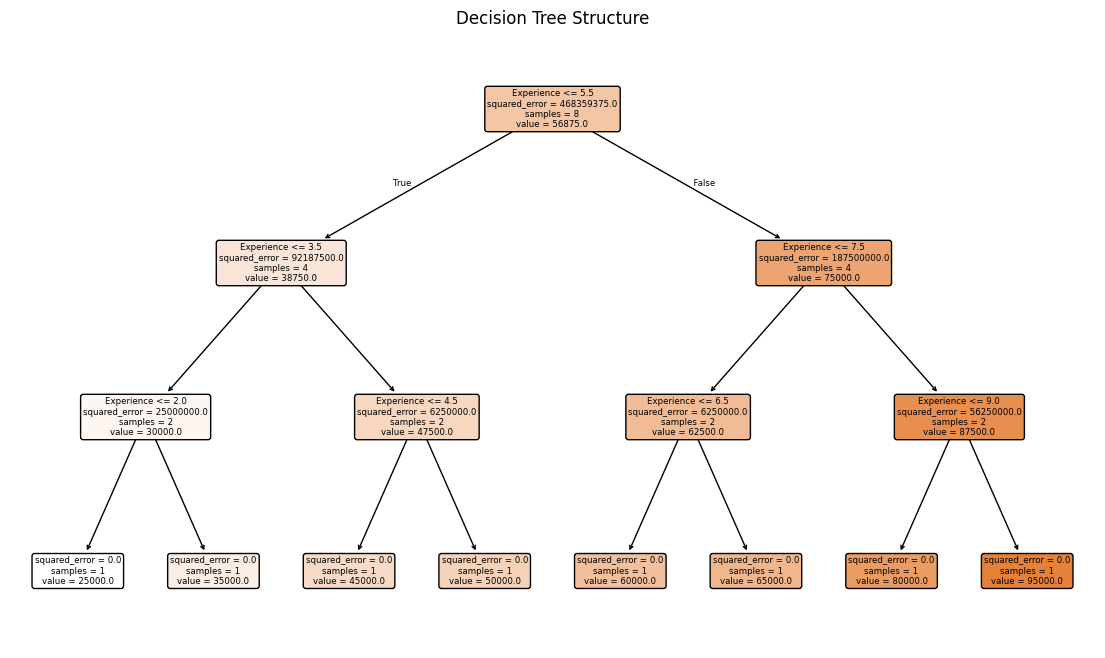

In [1]:
# Decision Tree Regression - Complete Proper Example

# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --------------------------------------------------
# Step 1: Create Dataset
# Example: Years of Experience -> Salary
# --------------------------------------------------

data = {
    "Experience": [1,2,3,4,5,6,7,8,9,10],
    "Salary":     [25000,30000,35000,45000,50000,60000,65000,80000,85000,95000]
}

df = pd.DataFrame(data)

print(df)

# --------------------------------------------------
# Step 2: Input and Output
# --------------------------------------------------

X = df[["Experience"]]   # Feature must be 2D
y = df["Salary"]         # Target

# --------------------------------------------------
# Step 3: Train Test Split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# --------------------------------------------------
# Step 4: Create Model
# --------------------------------------------------

model = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# --------------------------------------------------
# Step 5: Train Model
# --------------------------------------------------

model.fit(X_train, y_train)

# --------------------------------------------------
# Step 6: Prediction
# --------------------------------------------------

y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred)

# --------------------------------------------------
# Step 7: Evaluation
# --------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("\nMean Squared Error :", mse)
print("Mean Absolute Error:", mae)
print("R2 Score           :", r2)

# --------------------------------------------------
# Step 8: Predict New Value
# --------------------------------------------------

new_data = [[6.5]]
prediction = model.predict(new_data)

print("\nPredicted Salary for 6.5 years experience:")
print(prediction[0])

# --------------------------------------------------
# Step 9: Graph Regression Result
# --------------------------------------------------

X_grid = np.arange(min(X.values), max(X.values), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))

plt.figure(figsize=(10,6))
plt.scatter(X, y, color="red", label="Actual Data")
plt.plot(X_grid, model.predict(X_grid), color="blue", label="Decision Tree")
plt.title("Decision Tree Regression")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()

# --------------------------------------------------
# Step 10: Visualize Tree Structure
# --------------------------------------------------

plt.figure(figsize=(14,8))
plot_tree(
    model,
    feature_names=["Experience"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree Structure")
plt.show()